## Notebook 03b: Remaining Term Adjustment

**Extending the Markov framework with loan-specific time horizons**

The fundamental matrix in Notebook 04 computes infinite-horizon absorption probabilities.
This assumes loans run forever — which is not realistic.

This notebook computes a **within-term default probability** for each account:
the probability of defaulting before their loan actually matures.

For an account with `remaining_months` left, we compute P^remaining_months[state, Default].
This gives every account a personalised default probability based on their actual remaining time.

**Example:**
- High risk, 3 months left:  P³[High, Default] = probability of defaulting in 3 months
- High risk, 12 months left: P¹²[High, Default] = probability of defaulting in 12 months
- High risk, 36 months left: P³⁶[High, Default] = probability of defaulting in 36 months

A customer with 3 months left who is already High risk is in immediate danger.
A customer with 36 months left who is High risk has more time but is still at risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from numpy.linalg import matrix_power
warnings.filterwarnings('ignore')

STATES = ['Low', 'Medium', 'High', 'Default']
COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Default': '#8e44ad'}

# Load transition matrix
P_df = pd.read_csv('bk_transition_matrix.csv', index_col=0)
P_df = P_df.reindex(index=STATES, columns=STATES)
P = P_df.values

# Load current portfolio — most recent month only
df_all = pd.read_csv('bk_sentinel_verified.csv', low_memory=False)
latest_month = df_all['observation_month'].max()
df = df_all[df_all['observation_month'] == latest_month].copy()

print(f'Transition matrix loaded.')
print(f'Current portfolio snapshot: {latest_month}')
print(f'Total accounts: {len(df):,}')
print(f'\nRisk state distribution:')
print(df['risk_state'].value_counts())

Transition matrix loaded.
Current portfolio snapshot: 2026-01
Total accounts: 4,243

Risk state distribution:
risk_state
Low        2686
Default    1201
Medium      232
High        124
Name: count, dtype: int64


In [2]:
# Compute remaining months for each account
# remaining_months = loan_term_months - loan_age_months

if 'loan_age_months' in df.columns and 'loan_term_months' in df.columns:
    df['remaining_months'] = (
        df['loan_term_months'] - df['loan_age_months']
    ).clip(lower=1).fillna(12).astype(int)
elif 'number_instalments_paid' in df.columns and 'loan_term_months' in df.columns:
    df['remaining_months'] = (
        df['loan_term_months'] - df['number_instalments_paid']
    ).clip(lower=1).fillna(12).astype(int)
else:
    df['remaining_months'] = 12
    print('WARNING: Could not compute remaining months. Defaulting to 12.')

print('Remaining months distribution:')
print(df['remaining_months'].describe().round(1))
print(f'\nAccounts with <= 3 months remaining: {(df["remaining_months"] <= 3).sum():,}')
print(f'Accounts with <= 6 months remaining: {(df["remaining_months"] <= 6).sum():,}')
print(f'Accounts with > 24 months remaining: {(df["remaining_months"] > 24).sum():,}')

Remaining months distribution:
count    4243.0
mean       21.4
std        32.8
min         1.0
25%         2.0
50%         3.0
75%        36.0
max       304.0
Name: remaining_months, dtype: float64

Accounts with <= 3 months remaining: 2,155
Accounts with <= 6 months remaining: 2,237
Accounts with > 24 months remaining: 1,409


In [3]:
# Pre-compute P^n for all unique remaining month values
# This avoids recomputing the same matrix power repeatedly

unique_months = sorted(df['remaining_months'].unique())
# Cap at 60 months for computation efficiency
unique_months = [min(m, 60) for m in unique_months]
unique_months = sorted(set(unique_months))

print(f'Computing P^n for {len(unique_months)} unique remaining month values...')
print(f'Range: {min(unique_months)} to {max(unique_months)} months')

# Cache matrix powers
P_powers = {}
for n in unique_months:
    P_powers[n] = matrix_power(P, n)

print('Matrix powers computed successfully.')

# Map state to index
state_to_idx = {s: i for i, s in enumerate(STATES)}
default_idx = state_to_idx['Default']

Computing P^n for 60 unique remaining month values...
Range: 1 to 60 months
Matrix powers computed successfully.


In [4]:
# Compute within-term default probability for each account
def get_within_term_prob(row):
    state = row['risk_state']
    remaining = min(int(row['remaining_months']), 60)
    if state not in state_to_idx:
        return np.nan
    state_idx = state_to_idx[state]
    Pn = P_powers.get(remaining, P_powers[max(P_powers.keys())])
    return Pn[state_idx, default_idx]

df['within_term_default_prob'] = df.apply(get_within_term_prob, axis=1)

print('Within-term default probability computed for all accounts.')
print(f'\nAverage by risk state:')
for state in ['Low', 'Medium', 'High', 'Default']:
    subset = df[df['risk_state'] == state]['within_term_default_prob']
    if len(subset) > 0:
        print(f'  {state:<10}: mean = {subset.mean():.4f} ({subset.mean()*100:.1f}%), '
              f'min = {subset.min():.4f}, max = {subset.max():.4f}')

Within-term default probability computed for all accounts.

Average by risk state:
  Low       : mean = 0.1936 (19.4%), min = 0.0029, max = 0.5952
  Medium    : mean = 0.2335 (23.4%), min = 0.0009, max = 0.6743
  High      : mean = 0.5129 (51.3%), min = 0.2224, max = 0.8429
  Default   : mean = 0.9703 (97.0%), min = 0.9192, max = 0.9972


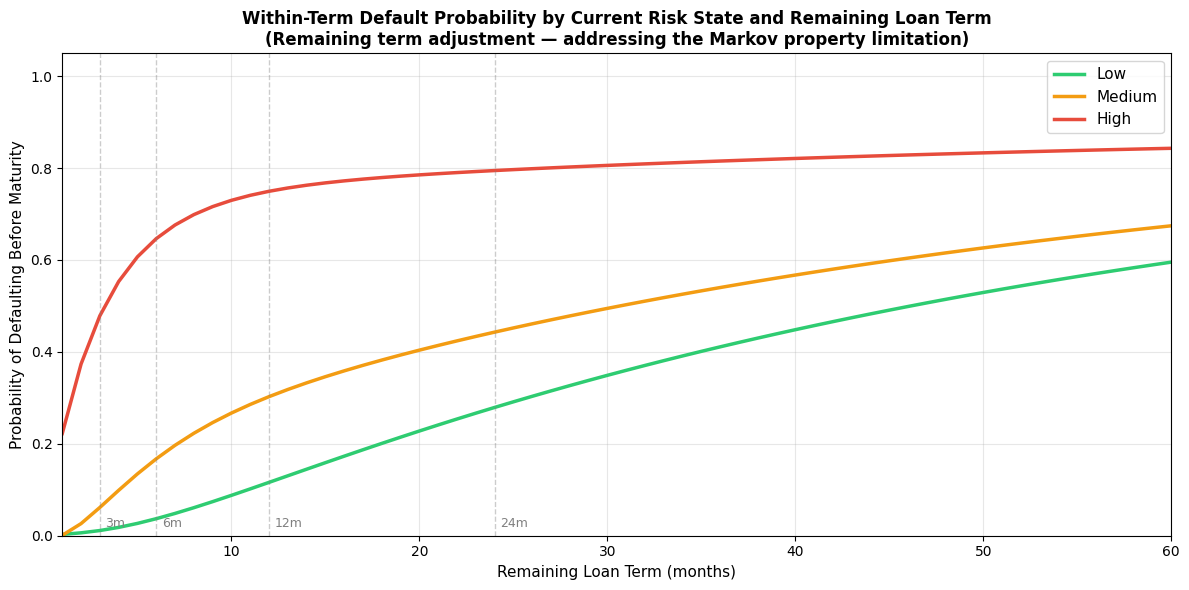

Chart saved.


In [5]:
# Show how within-term default probability changes with remaining months
# for each starting risk state

horizon_range = list(range(1, 61))
fig, ax = plt.subplots(figsize=(12, 6))

for state in ['Low', 'Medium', 'High']:
    state_idx = state_to_idx[state]
    probs = [matrix_power(P, n)[state_idx, default_idx] for n in horizon_range]
    ax.plot(horizon_range, probs, marker='', linewidth=2.5,
            label=state, color=COLORS[state])

# Add reference lines
for months in [3, 6, 12, 24]:
    ax.axvline(x=months, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(months+0.3, 0.02, f'{months}m', fontsize=9, color='gray')

ax.set_xlabel('Remaining Loan Term (months)', fontsize=11)
ax.set_ylabel('Probability of Defaulting Before Maturity', fontsize=11)
ax.set_title('Within-Term Default Probability by Current Risk State and Remaining Loan Term\n'
             '(Remaining term adjustment — addressing the Markov property limitation)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 60)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('03b_within_term_default_prob.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [6]:
# Show the critical case — High risk accounts with very little time remaining
print('CRITICAL ACCOUNTS: High risk with <= 6 months remaining')
print('=' * 60)

critical = df[
    (df['risk_state'] == 'High') &
    (df['remaining_months'] <= 6)
][['loan_id', 'customer_id', 'risk_state',
   'days_in_arrears', 'remaining_months',
   'within_term_default_prob']].sort_values(
       'within_term_default_prob', ascending=False
)

print(f'\nTotal critical accounts: {len(critical):,}')
if len(critical) > 0:
    print(f'\nTop 10 most urgent accounts:')
    print(critical.head(10).to_string(index=False))
else:
    print('No High-risk accounts with <= 6 months remaining in current snapshot.')
    # Show all High risk accounts instead
    high_risk = df[df['risk_state'] == 'High'][[
        'loan_id', 'risk_state', 'days_in_arrears',
        'remaining_months', 'within_term_default_prob'
    ]].sort_values('within_term_default_prob', ascending=False)
    print(f'\nAll High-risk accounts ranked by within-term default probability:')
    print(high_risk.head(10).to_string(index=False))

CRITICAL ACCOUNTS: High risk with <= 6 months remaining

Total critical accounts: 79

Top 10 most urgent accounts:
 loan_id     customer_id risk_state  days_in_arrears  remaining_months  within_term_default_prob
LN996302 ANON_5F25152A73       High               81                 6                  0.646432
LN202400 ANON_51BC374722       High               73                 4                  0.553042
LN647496 ANON_AAF95B062E       High               35                 3                  0.478619
LN740790 ANON_5DBECCDF3C       High               90                 3                  0.478619
LN365926 ANON_7432C391B1       High               80                 3                  0.478619
LN369236 ANON_48743416B6       High               49                 3                  0.478619
LN733564 ANON_E979946B18       High               75                 3                  0.478619
LN683982 ANON_88680CC897       High               79                 3                  0.478619
LN653560 ANO

In [7]:
# Compare: standard absorption probability vs within-term probability
# Load the infinite-horizon probabilities from Notebook 04
try:
    absorption_df = pd.read_csv('bk_time_to_absorption.csv')
    infinite_probs = dict(zip(absorption_df['risk_state'],
                               absorption_df['absorption_probability']))
    has_absorption = True
except:
    has_absorption = False
    print('Note: bk_time_to_absorption.csv not found. Run Notebook 04 first.')

# Comparison table
print('COMPARISON: Infinite-horizon vs Within-term default probability')
print('=' * 70)
print(f'{"State":<10} {"Remaining":>12} {"Within-term":>14} {"Infinite-horizon":>18}')
print('-' * 70)

for state in ['Low', 'Medium', 'High']:
    state_idx = state_to_idx[state]
    for remaining in [3, 6, 12, 24, 36]:
        Pn = matrix_power(P, remaining)
        within = Pn[state_idx, default_idx]
        infinite = infinite_probs.get(state, 'N/A') if has_absorption else 'N/A'
        infinite_str = f'{infinite*100:.1f}%' if isinstance(infinite, float) else infinite
        print(f'{state:<10} {remaining:>8} months   {within*100:>10.1f}%   {infinite_str:>16}')
    print()

COMPARISON: Infinite-horizon vs Within-term default probability
State         Remaining    Within-term   Infinite-horizon
----------------------------------------------------------------------
Low               3 months          1.1%             100.0%
Low               6 months          3.7%             100.0%
Low              12 months         11.6%             100.0%
Low              24 months         27.9%             100.0%
Low              36 months         41.1%             100.0%

Medium            3 months          6.2%             100.0%
Medium            6 months         16.7%             100.0%
Medium           12 months         30.3%             100.0%
Medium           24 months         44.3%             100.0%
Medium           36 months         54.0%             100.0%

High              3 months         47.9%             100.0%
High              6 months         64.6%             100.0%
High             12 months         74.9%             100.0%
High             24 month

In [8]:
# Early warning watchlist — ranked by within-term default probability
# This is the most actionable output for BK credit analysts

watchlist = df[
    df['risk_state'].isin(['Medium', 'High'])
][['loan_id', 'customer_id', 'risk_state', 'segment',
   'days_in_arrears', 'instalments_in_arrears',
   'remaining_months', 'within_term_default_prob']].copy()

watchlist = watchlist.sort_values('within_term_default_prob', ascending=False)
watchlist['urgency'] = pd.cut(
    watchlist['within_term_default_prob'],
    bins=[0, 0.20, 0.50, 0.75, 1.01],
    labels=['Low urgency', 'Medium urgency', 'High urgency', 'CRITICAL']
)

print('WITHIN-TERM EARLY WARNING WATCHLIST')
print('=' * 60)
print(f'Total accounts on watchlist: {len(watchlist):,}')
print(f'\nUrgency breakdown:')
print(watchlist['urgency'].value_counts().to_string())
print(f'\nTop 15 most urgent accounts:')
print(watchlist.head(15).to_string(index=False))

# Save watchlist
watchlist.to_csv('bk_within_term_watchlist.csv', index=False)
df[['loan_id', 'customer_id', 'risk_state', 'remaining_months',
    'within_term_default_prob']].to_csv('bk_within_term_default_probs.csv', index=False)

print('\nFiles saved:')
print('  bk_within_term_watchlist.csv')
print('  bk_within_term_default_probs.csv')

WITHIN-TERM EARLY WARNING WATCHLIST
Total accounts on watchlist: 356

Urgency breakdown:
urgency
Low urgency       137
Medium urgency    110
High urgency       75
CRITICAL           34

Top 15 most urgent accounts:
 loan_id     customer_id risk_state segment  days_in_arrears  instalments_in_arrears  remaining_months  within_term_default_prob  urgency
LN726960 ANON_82F5D3CC4D       High  RETAIL               44                       2                61                  0.842935 CRITICAL
LN641634 ANON_ECE8E7730E       High  RETAIL               46                       4               239                  0.842935 CRITICAL
LN272351 ANON_D65BC73D1D       High     SME               42                       2               118                  0.842935 CRITICAL
LN471716 ANON_A5F8A59984       High  RETAIL               75                       2                60                  0.842935 CRITICAL
LN632531 ANON_5EE4626E6C       High  RETAIL               67                       2           

In [9]:
# Key findings summary
print('=' * 60)
print('REMAINING TERM ADJUSTMENT — KEY FINDINGS')
print('=' * 60)
state_idx = state_to_idx['High']
for remaining in [3, 6, 12, 24]:
    prob = matrix_power(P, remaining)[state_idx, default_idx]
    print(f'  High risk, {remaining:>2} months remaining: {prob*100:.1f}% chance of defaulting before maturity')

print()
print('This shows why remaining term matters:')
print('A High-risk account with 3 months left has almost no recovery window.')
print('A High-risk account with 24 months left still has time for intervention.')
print('The standard Markov infinite-horizon probability does not distinguish these two cases.')
print('The within-term adjustment gives credit analysts a more precise urgency signal.')
print()
print('This directly addresses the Markov property limitation identified in Section 3.9')
print('of the BK Sentinel research proposal.')

REMAINING TERM ADJUSTMENT — KEY FINDINGS
  High risk,  3 months remaining: 47.9% chance of defaulting before maturity
  High risk,  6 months remaining: 64.6% chance of defaulting before maturity
  High risk, 12 months remaining: 74.9% chance of defaulting before maturity
  High risk, 24 months remaining: 79.5% chance of defaulting before maturity

This shows why remaining term matters:
A High-risk account with 3 months left has almost no recovery window.
A High-risk account with 24 months left still has time for intervention.
The standard Markov infinite-horizon probability does not distinguish these two cases.
The within-term adjustment gives credit analysts a more precise urgency signal.

This directly addresses the Markov property limitation identified in Section 3.9
of the BK Sentinel research proposal.
